In [1]:
# Disable JAXFEM logging
import jax_fem                       # forces setup_logger() to run NOW
import logging
jl = logging.getLogger('jax_fem')
jl.setLevel(logging.WARNING)         # or logging.ERROR to also silence INFO
jl.handlers.clear()                  # remove jax_fem's own StreamHandler
jl.propagate = False

import os, glob
import numpy as np
import pyvista as pv
from simsopt import load, save
from simsopt.configs import get_data
from simsopt.geo import plot, CurveLength
from simsopt.field import (
    BiotSavart, Current,
    coils_via_symmetries,
    RegularizedCoil, LpCurveForce,
)
from coilforce.support import CoilSupportDiscrete, CoilSupportTopBottom
from coilforce.simsopt_bridge import CoilFEMObjective
from optimization import (
    load_eq, 
    run_filament_free, 
    increase_base_curve_order,
    mesh_options,
    problem_options,
    material_options_const_temp,
    material_options_variable_temp,
)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



In [2]:
# Movable-configuration stress objective (case C).
Jstress_movable = load('Jstress_movable.json')[0]

In [3]:
# Regenerate the two datasets we compare:
#   fem_data_movable         — as-built (thermal contraction on, itc from properties.json)
#   fem_data_movable_no_itc  — identical setup but with thermal contraction off (itc = 0)
# The no-itc copy reuses every constructor argument of Jstress_movable and
# overrides only itc, so the FEM problems are rebuilt with a zero thermal eigenstrain.
from pathlib import Path

mat_no_itc = dict(Jstress_movable._material_options or {})
mat_no_itc['itc'] = 0.0

Jstress_movable_no_itc = CoilFEMObjective(
    base_curves      = Jstress_movable._base_curves,
    base_currents    = Jstress_movable._base_currents,
    base_supports    = Jstress_movable._base_supports,
    metrics          = Jstress_movable._metrics,
    metric_weights   = Jstress_movable._metric_weights,
    nfp              = Jstress_movable._nfp,
    stellsym         = Jstress_movable._stellsym,
    mesh_options     = Jstress_movable._mesh_options,
    material_options = mat_no_itc,
    problem_options  = Jstress_movable._problem_options,
    gravity_options  = Jstress_movable._gravity_options,
)

if not Path('fem_data_movable').is_dir():
    Jstress_movable.save_run_vtu('fem_data_movable', prefix='coil_')
if not Path('fem_data_movable_no_itc').is_dir():
    Jstress_movable_no_itc.save_run_vtu('fem_data_movable_no_itc', prefix='coil_')

In [4]:
import os, glob
import numpy as np
import pyvista as pv
import vtk   # for custom colorbar tick labels

# ---- the two datasets to compare ----
folders = ['fem_data_movable', 'fem_data_movable_no_itc']
quantity = 'von_mises_MPa'
# --------------------------------------


# Load each folder's 5 vtu files once and merge them into a single object
meshes = {}
for f in folders:
    parts = [pv.read(p) for p in sorted(glob.glob(os.path.join(f, '*.vtu')))]
    meshes[f] = pv.merge(parts)        # all 5 meshes -> one combined mesh

def values(mesh, q):                   # handle scalar OR vector/tensor cell data
    a = np.asarray(mesh.cell_data[q])
    return np.linalg.norm(a, axis=1) if a.ndim == 2 and a.shape[1] > 1 else a.ravel()

# ---- camera / layout knobs ----
zoom        = 1.8     # >1 zooms in, <1 zooms out
azimuth_deg = 180     # rotate camera around the origin in the xy-plane
panel_px    = 1200     # square subplot size (pixels) -> window is (panel_px*N, panel_px)
glyph_scale = 0.02     # sphere radius [m] at support_weight == 1 (0 disables glyphs)
edge_angle  = 15      # deg; larger -> fewer edges kept (only sharper creases)
tick_interval = 200   # colorbar tick spacing (data units, e.g. MPa)
# --------------------------------

# ---- element-edge (tet10 wireframe) knobs ----
show_element_edges = True     # overlay the true quadratic element edges
edge_color         = 'grey'
edge_width         = 1.0
edge_opacity       = 1.0
edge_subdiv        = 8        # straight segments per quadratic edge (higher -> smoother curves)
edge_dedup         = True     # draw each shared edge only once
# ----------------------------------------------

def surface_edges(mesh, angle):
    """Clean wireframe: boundary + feature (crease) edges of the outer surface.

    Avoids the tet-diagonal clutter you get from add_mesh(show_edges=True)."""
    return mesh.extract_surface().extract_feature_edges(
        feature_angle=angle,
        boundary_edges=True,
        feature_edges=True,
        manifold_edges=False,
        non_manifold_edges=False,
    )

# VTK quadratic-tetra local node order for the 6 element edges: (corner_a, midside, corner_b)
_TET10_EDGES = np.array([
    [0, 4, 1],
    [1, 5, 2],
    [2, 6, 0],
    [0, 7, 3],
    [1, 8, 3],
    [2, 9, 3],
], dtype=np.int64)

def tet10_edge_lines(mesh, n_sub=8, dedup=True):
    """True curved edges of a quadratic-tetrahedron (tet10) mesh.

    Every element has 6 quadratic edges (2 corner nodes + 1 mid-side node). Each
    edge is sampled with ``n_sub`` straight segments via the quadratic shape
    functions, so the parabolic curvature carried by the mid-side node is drawn
    faithfully -- unlike add_mesh(show_edges=True), which draws the tessellation
    diagonals, or a plain corner-to-corner wireframe, which ignores the curvature.

    Only VTK_QUADRATIC_TETRA (type 24) cells contribute. Returns a PolyData of
    polylines; each shared edge is drawn once when ``dedup`` is True.
    """
    cd = mesh.cells_dict
    if 24 not in cd:                        # nothing quadratic -> fall back to straight edges
        return mesh.extract_all_edges()

    cells = np.asarray(cd[24])              # (m, 10) tet10 connectivity
    edges = cells[:, _TET10_EDGES].reshape(-1, 3)   # (6m, 3): corner_a, mid, corner_b

    if dedup:                               # keep each undirected corner pair once
        key = np.sort(edges[:, ::2], axis=1)
        _, keep = np.unique(key, axis=0, return_index=True)
        edges = edges[keep]

    pts = np.asarray(mesh.points, dtype=float)
    p0, pm, p1 = pts[edges[:, 0]], pts[edges[:, 1]], pts[edges[:, 2]]

    # quadratic Lagrange basis for nodes at t = 0, 0.5, 1
    t  = np.linspace(0.0, 1.0, n_sub + 1)
    N0 = (2.0 * t - 1.0) * (t - 1.0)
    Nm = 4.0 * t * (1.0 - t)
    N1 = t * (2.0 * t - 1.0)
    sample = (N0[None, :, None] * p0[:, None, :]
              + Nm[None, :, None] * pm[:, None, :]
              + N1[None, :, None] * p1[:, None, :])       # (E, S, 3)

    E, S  = edges.shape[0], n_sub + 1
    ids   = np.arange(E * S, dtype=np.int64).reshape(E, S)
    lines = np.hstack([np.full((E, 1), S, dtype=np.int64), ids]).ravel()
    return pv.PolyData(sample.reshape(-1, 3), lines=lines)

def make_support_glyphs(mesh, scale):
    """Grey sphere glyphs at supported nodes, radius proportional to weight."""
    if scale <= 0 or "support_weights" not in mesh.point_data:
        return None
    w = np.asarray(mesh.point_data["support_weights"]).ravel()
    mask = w > 0.0
    if not mask.any():
        return None
    cloud = pv.PolyData(np.asarray(mesh.points)[mask])
    cloud["support_weights"] = w[mask]
    # pv.Sphere has radius 0.5, so factor=2*scale gives radius==scale at weight 1
    sphere = pv.Sphere(theta_resolution=12, phi_resolution=12)
    return cloud.glyph(scale="support_weights", geom=sphere,
                       factor=3.0 * scale, orient=False)

def rotate_camera_xy(plotter, angle_deg, center=(0.0, 0.0, 0.0)):
    '''Rotate the (shared) camera in xy about the z-axis through ``center``.'''
    th = np.radians(angle_deg)
    c, s = np.cos(th), np.sin(th)
    R = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])
    ctr = np.asarray(center, dtype=float)
    cam = plotter.camera
    cam.position    = tuple(ctr + R @ (np.asarray(cam.position)    - ctr))
    cam.focal_point = tuple(ctr + R @ (np.asarray(cam.focal_point) - ctr))
    cam.up          = tuple(R @ np.asarray(cam.up))   # direction: no translation

# Rotation center = mean of all vertices across all coils/folders
center = np.vstack([np.asarray(meshes[f].points) for f in folders]).mean(axis=0) + np.array([0,0.2,0])

# Precompute the tet10 wireframe once per folder (independent of the quantity)
edge_lines = ({f: tet10_edge_lines(meshes[f], n_sub=edge_subdiv, dedup=edge_dedup)
               for f in folders} if show_element_edges else {})

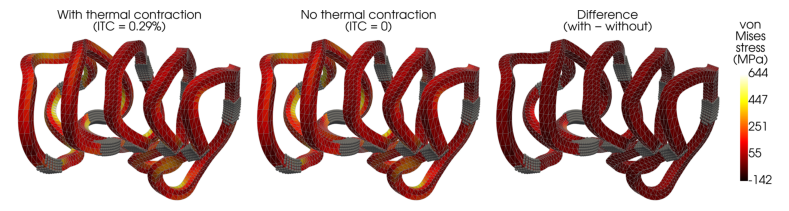

In [5]:
# ── Full von Mises stress: with, without, and difference (movable) ────────────
# Three panels sharing ONE colorbar: with thermal (itc), without thermal (itc=0),
# and their difference (with − without).  Same camera/zoom/edges/glyphs style.
import math

mesh_with = meshes['fem_data_movable']
mesh_wo   = meshes['fem_data_movable_no_itc']
names = {
    'fem_data_movable':        'With thermal contraction\n(ITC = 0.29%)',
    'fem_data_movable_no_itc': 'No thermal contraction\n(ITC = 0)',
}
vm_with = values(mesh_with, quantity)
vm_wo   = values(mesh_wo,   quantity)
assert vm_with.shape == vm_wo.shape, "meshes differ in cell count; cannot difference"

# Difference field lives on a copy of the movable mesh (identical topology).
diff_q    = quantity + '_diff'
mesh_diff = mesh_with.copy()
mesh_diff.cell_data[diff_q] = np.abs(vm_with - vm_wo)

panels = [
    (mesh_with, quantity, names['fem_data_movable']),
    (mesh_wo,   quantity, names['fem_data_movable_no_itc']),
    (mesh_diff, diff_q,   'Difference\n(with − without)'),
]

# One shared color range spanning all three panels.
allvals = np.concatenate([vm_with, vm_wo, vm_with - vm_wo])
clim = (float(allvals.min()), float(allvals.max()))

ncols     = 3
cbar_frac = 0.22
panel_h   = int(panel_px * 0.8)
p = pv.Plotter(shape=(1, ncols + 1), off_screen=True,
               groups=[(np.s_[:], ncols)],                 # colorbar column
               col_weights=[1.0] * ncols + [cbar_frac],
               window_size=(int(panel_px * (ncols + cbar_frac)), panel_h),
               border=False)
for i, (mesh_i, q_i, title) in enumerate(panels):
    p.subplot(0, i)
    p.add_text(title, font_size=25, position='upper_edge')
    actor = p.add_mesh(mesh_i, scalars=q_i, preference='cell', clim=clim,
                       cmap='hot', show_scalar_bar=False)
    bar_mapper = actor.mapper
    if show_element_edges:
        ea = p.add_mesh(edge_lines['fem_data_movable'], color=edge_color,
                        line_width=edge_width, opacity=edge_opacity,
                        show_scalar_bar=False)
        try:
            ea.mapper.SetResolveCoincidentTopologyToPolygonOffset()
            ea.mapper.SetRelativeCoincidentTopologyLineOffsetParameters(-1.0, -1.0)
        except Exception:
            pass
    glyphs = make_support_glyphs(mesh_i, glyph_scale)
    if glyphs is not None:
        p.add_mesh(glyphs, color='grey', show_scalar_bar=False)

# Identical camera treatment.
p.link_views()
p.subplot(0, 0)
p.view_isometric()
rotate_camera_xy(p, azimuth_deg, center=center)
p.camera.zoom(zoom)

# One shared colorbar (plain-text title -> avoids the VTK/matplotlib mathtext hang).
p.subplot(0, ncols)
sb = p.add_scalar_bar(
    title="von\nMises\nstress\n(MPa)", mapper=bar_mapper, vertical=True,
    position_x=0.24, position_y=0.1, height=0.8, width=0.4,
    title_font_size=60, label_font_size=60, fmt="%.0f",
)

img = p.screenshot('../figures/figure_movable_vm_itc_vs_no_itc.png')
p.close()

import matplotlib.pyplot as plt
ih, iw = img.shape[:2]
fig, ax = plt.subplots(figsize=(10, 10 * ih / iw))
ax.imshow(img); ax.axis('off'); plt.show()
pv.close_all(); plt.close('all')

In [6]:
# ── von Mises stress stats + normalized error: with vs without thermal ────────
# Per-dataset volume-weighted RMS and max, plus the normalized error field
#   norm_err_von_mises = (vm_with_itc - vm_no_itc) / vm_with_itc      (per cell)
# reported as a volume-weighted RMS and a max absolute value.
m_with = meshes['fem_data_movable']
m_wo   = meshes['fem_data_movable_no_itc']
V = np.abs(np.asarray(
    m_with.compute_cell_sizes(length=False, area=False, volume=True).cell_data['Volume']))
vm_with = values(m_with, quantity)
vm_wo   = values(m_wo,   quantity)

def _vol_rms(a, w):
    return float(np.sqrt(np.sum(a**2 * w) / np.sum(w)))

print("von Mises stress [MPa] — movable configuration")
print(f"  with thermal (itc)   RMS(vol-wtd)={_vol_rms(vm_with, V):10.3f}   max={float(vm_with.max()):10.3f}")
print(f"  no thermal   (itc=0) RMS(vol-wtd)={_vol_rms(vm_wo,   V):10.3f}   max={float(vm_wo.max()):10.3f}")

with np.errstate(divide='ignore', invalid='ignore'):
    norm_err_von_mises = (vm_with - vm_wo) / vm_with
mask = np.isfinite(norm_err_von_mises)
print("normalized error  (vm_with_itc - vm_no_itc) / vm_with_itc")
print(f"  RMS(vol-wtd)={_vol_rms(norm_err_von_mises[mask], V[mask]):.4e}   "
      f"max|·|={float(np.abs(norm_err_von_mises[mask]).max()):.4e}")

von Mises stress [MPa] — movable configuration
  with thermal (itc)   RMS(vol-wtd)=   152.879   max=   643.816
  no thermal   (itc=0) RMS(vol-wtd)=   147.480   max=   534.190
normalized error  (vm_with_itc - vm_no_itc) / vm_with_itc
  RMS(vol-wtd)=2.0073e-01   max|·|=1.4304e+00


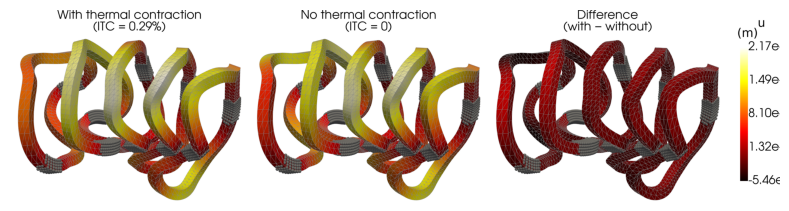

In [7]:
# ── Displacement magnitude |u| [m]: with, without, and difference (movable) ────
# Three panels sharing ONE colorbar, same styling as the von Mises figure.
import math

mesh_with = meshes['fem_data_movable']
mesh_wo   = meshes['fem_data_movable_no_itc']

u_with = np.linalg.norm(np.asarray(mesh_with.point_data['displacement_m']), axis=1)
u_wo   = np.linalg.norm(np.asarray(mesh_wo.point_data['displacement_m']),   axis=1)
assert u_with.shape == u_wo.shape, "meshes differ in point count; cannot difference"

mesh_with.point_data['u_mag_m'] = u_with
mesh_wo.point_data['u_mag_m']   = u_wo
mesh_diff = mesh_with.copy()
mesh_diff.point_data['u_mag_diff_m'] = u_with - u_wo

panels_u = [
    (mesh_with, 'u_mag_m',      names['fem_data_movable']),
    (mesh_wo,   'u_mag_m',      names['fem_data_movable_no_itc']),
    (mesh_diff, 'u_mag_diff_m', 'Difference\n(with − without)'),
]

# One shared color range spanning all three panels.
allvals = np.concatenate([u_with, u_wo, u_with - u_wo])
clim = (float(allvals.min()), float(allvals.max()))

ncols     = 3
cbar_frac = 0.22
panel_h   = int(panel_px * 0.8)
p = pv.Plotter(shape=(1, ncols + 1), off_screen=True,
               groups=[(np.s_[:], ncols)],                 # colorbar column
               col_weights=[1.0] * ncols + [cbar_frac],
               window_size=(int(panel_px * (ncols + cbar_frac)), panel_h),
               border=False)
for i, (mesh_i, q_i, title) in enumerate(panels_u):
    p.subplot(0, i)
    p.add_text(title, font_size=25, position='upper_edge')
    actor = p.add_mesh(mesh_i, scalars=q_i, preference='point', clim=clim,
                       cmap='hot', show_scalar_bar=False)
    bar_mapper = actor.mapper
    if show_element_edges:
        ea = p.add_mesh(edge_lines['fem_data_movable'], color=edge_color,
                        line_width=edge_width, opacity=edge_opacity,
                        show_scalar_bar=False)
        try:
            ea.mapper.SetResolveCoincidentTopologyToPolygonOffset()
            ea.mapper.SetRelativeCoincidentTopologyLineOffsetParameters(-1.0, -1.0)
        except Exception:
            pass
    glyphs = make_support_glyphs(mesh_i, glyph_scale)
    if glyphs is not None:
        p.add_mesh(glyphs, color='grey', show_scalar_bar=False)

# Identical camera treatment.
p.link_views()
p.subplot(0, 0)
p.view_isometric()
rotate_camera_xy(p, azimuth_deg, center=center)
p.camera.zoom(zoom)

# One shared colorbar (plain-text title -> avoids the VTK/matplotlib mathtext hang).
p.subplot(0, ncols)
sb = p.add_scalar_bar(
    title="|u|\n(m)", mapper=bar_mapper, vertical=True,
    position_x=0.24, position_y=0.1, height=0.8, width=0.4,
    title_font_size=60, label_font_size=60, fmt="%.2e",
)

img = p.screenshot('../figures/figure_movable_umag_itc_vs_no_itc.png')
p.close()

import matplotlib.pyplot as plt
ih, iw = img.shape[:2]
fig, ax = plt.subplots(figsize=(10, 10 * ih / iw))
ax.imshow(img); ax.axis('off'); plt.show()
pv.close_all(); plt.close('all')

In [ ]:
# ── |u| stats + normalized error: with vs without thermal ─────────────────────
# Per-dataset nodal RMS and max, plus the normalized error field
#   norm_err_u = (|u|_with_itc - |u|_no_itc) / |u|_with_itc          (per node)
# reported as nodal RMS and max absolute value.  Nodes with |u|_with == 0
# (e.g. clamped supports) are excluded from the normalized error.
u_with = np.linalg.norm(np.asarray(meshes['fem_data_movable'].point_data['displacement_m']),        axis=1)
u_wo   = np.linalg.norm(np.asarray(meshes['fem_data_movable_no_itc'].point_data['displacement_m']), axis=1)

print("displacement magnitude |u| [m] — movable configuration")
print(f"  with thermal (itc)   RMS(nodal)={float(np.sqrt(np.mean(u_with**2))):.4e}   max={float(u_with.max()):.4e}")
print(f"  no thermal   (itc=0) RMS(nodal)={float(np.sqrt(np.mean(u_wo**2))):.4e}   max={float(u_wo.max()):.4e}")

with np.errstate(divide='ignore', invalid='ignore'):
    norm_err_u = (u_with - u_wo) / u_with
mask = np.isfinite(norm_err_u)
print("normalized error  (|u|_with_itc - |u|_no_itc) / |u|_with_itc")
print(f"  RMS(nodal)={float(np.sqrt(np.mean(norm_err_u[mask]**2))):.4e}   "
      f"max|·|={float(np.abs(norm_err_u[mask]).max()):.4e}")